# MLP Inverse Model 
**Inputs:** `mean_rssi_dbm` `loss_rate_pct`, `throughput_pkt_s`, `mean_delay_s`  
**Outputs:** `RSSI_INFLECTION_POINT`, `TRANSMITTING_RANGE`, `PATH_LOSS_EXPONENT`, `AWGN_SIGMA`

## 0. Install Dependencies

In [ ]:
pip install torch scikit-learn pandas numpy matplotlib joblib --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## 1. Imports & Config

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# ── CHANGE THIS ──────────────────────────────
CSV_PATH = 'dataset02.csv'
# ─────────────────────────────────────────────
FEATURE_COLS = [
    # Original
    'mean_rssi_dbm', 'loss_rate_pct', 'throughput_pkt_s', 'mean_delay_s',
    # Interaction terms
    'loss_x_delay', 'loss_x_throughput', 'delay_x_throughput',
    'rssi_x_loss', 'rssi_x_delay',
    # Ratio features
    'throughput_per_loss', 'delay_per_loss'
]

# DROP transmitting range from outputs
TARGET_COLS = ['RSSI_INFLECTION_POINT', 'PATH_LOSS_EXPONENT', 'AWGN_SIGMA','TRANSMITTING_RANGE']


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Load & Prepare Data

In [ ]:
df = pd.read_csv(CSV_PATH)
df['mean_rssi_dbm'] = df['mean_rssi_dbm'].fillna(-100.0)

# Interaction terms
df['loss_x_delay']        = df['loss_rate_pct']    * df['mean_delay_s']
df['loss_x_throughput']   = df['loss_rate_pct']    * df['throughput_pkt_s']
df['delay_x_throughput']  = df['mean_delay_s']     * df['throughput_pkt_s']
df['rssi_x_loss']         = df['mean_rssi_dbm']    * df['loss_rate_pct']
df['rssi_x_delay']        = df['mean_rssi_dbm']    * df['mean_delay_s']

# Ratio features
df['throughput_per_loss'] = df['throughput_pkt_s'] / (df['loss_rate_pct'] + 1e-6)
df['delay_per_loss']      = df['mean_delay_s']     / (df['loss_rate_pct'] + 1e-6)
print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Missing values: {df[FEATURE_COLS].isnull().sum().sum()} (none expected — RSSI removed)')
display(df[FEATURE_COLS + TARGET_COLS].describe())

Dataset: 5967 rows × 22 columns
Missing values: 0 (none expected — RSSI removed)


,mean_rssi_dbm,loss_rate_pct,throughput_pkt_s,mean_delay_s,loss_x_delay,loss_x_throughput,delay_x_throughput,rssi_x_loss,rssi_x_delay,throughput_per_loss,delay_per_loss,RSSI_INFLECTION_POINT,PATH_LOSS_EXPONENT,AWGN_SIGMA,TRANSMITTING_RANGE
count,5967.000000,5967.000000,5967.000000,5967.000000,5967.000000,5967.000000,5967.000000,5967.000000,5967.000000,5967.000000,5967.000000,5967.000000,5967.000000,5967.000000,5967.0
mean,-46.757902,48.153102,41.479174,0.843483,56.274796,1316.790610,22.459654,-2691.396490,-45.472041,1.484350,0.017257,-60.000000,3.000000,7.500000,100.0
std,23.027026,29.168600,23.335860,0.748507,81.030436,597.692172,10.432852,2624.082921,54.094961,1.084251,0.005550,18.709855,1.224848,3.894767,0.0
min,-100.000000,21.750000,0.000000,0.000000,0.000000,0.000000,0.000000,-10000.000000,-416.105459,0.000000,0.000000,-90.000000,1.000000,1.000000,100.0
25%,-63.910000,23.780000,21.185000,0.396196,9.336355,1395.000000,22.006936,-4162.674200,-56.942164,0.288172,0.016418,-75.000000,2.000000,4.000000,100.0
50%,-45.880000,31.670000,54.670000,0.487512,14.231748,1452.571200,24.403393,-1509.056500,-21.373766,1.726239,0.017198,-60.000000,3.000000,7.500000,100.0
75%,-28.155000,73.515000,60.980000,0.989406,60.609638,1684.524600,28.311549,-717.918000,-10.552308,2.564340,0.018419,-45.000000,4.000000,11.000000,100.0
max,-9.190000,100.000000,62.610000,6.664319,666.365257,2000.599800,42.146603,-212.247000,-0.000000,2.878621,0.066650,-30.000000,5.000000,14.000000,100.0


## 3. Train / Test Split & Scaling

In [ ]:
X = df[FEATURE_COLS].values
y = df[TARGET_COLS].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')

# Scale inputs
X_scaler   = StandardScaler()
X_train_sc = X_scaler.fit_transform(X_train)
X_test_sc  = X_scaler.transform(X_test)

# Scale outputs — critical for multi-output regression
y_scaler   = StandardScaler()
y_train_sc = y_scaler.fit_transform(y_train)
y_test_sc  = y_scaler.transform(y_test)

# Tensors
X_train_t = torch.FloatTensor(X_train_sc).to(device)
y_train_t = torch.FloatTensor(y_train_sc).to(device)
X_test_t  = torch.FloatTensor(X_test_sc).to(device)
y_test_t  = torch.FloatTensor(y_test_sc).to(device)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=16,   # ← smaller batch: more gradient updates per epoch
    shuffle=True
)

Train: 4773  |  Test: 1194


## 4. Model Architecture
Deeper network to compensate for fewer inputs: **11 → 64 → 128 → 256 → 128 → 64 → 3**

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim=4, output_dim=4):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),

            # Layer 2
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            # Layer 3 
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.1),

            # Layer 4 
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            # Layer 5
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            # Output
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        return self.network(x)

model = MLP(input_dim=11, output_dim=4)  
print('Architecture: 11 → 64 → 128 → 256 → 128 → 64 → 4')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

Architecture: 11 → 64 → 128 → 256 → 128 → 64 → 4
Total parameters: 84,804


## 5. Training

In [ ]:
EPOCHS              = 500
LR                  = 1e-3       
EARLY_STOP_PATIENCE = 80
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=40, factor=0.7
)

train_losses, val_losses = [], []
best_val_loss    = float('inf')
patience_counter = 0

print(f'Training (max {EPOCHS} epochs)...')
print(f'{"Epoch":<8} {"Train Loss":<14} {"Val Loss":<14} {"LR"}')
print('-' * 50)

for epoch in range(1, EPOCHS + 1):

    # ── Train ──
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    # ── Validate ──
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_test_t), y_test_t).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'mlp_best.pt')
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 20 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'{epoch:<8} {train_loss:<14.6f} {val_loss:<14.6f} {lr_now:.2e}')

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break

print(f'\nBest validation loss: {best_val_loss:.6f}')

Training (max 500 epochs)...
Epoch    Train Loss     Val Loss       LR
--------------------------------------------------
1        0.222678       0.221006       1.00e-03


KeyboardInterrupt: 

## 6. Training Curve

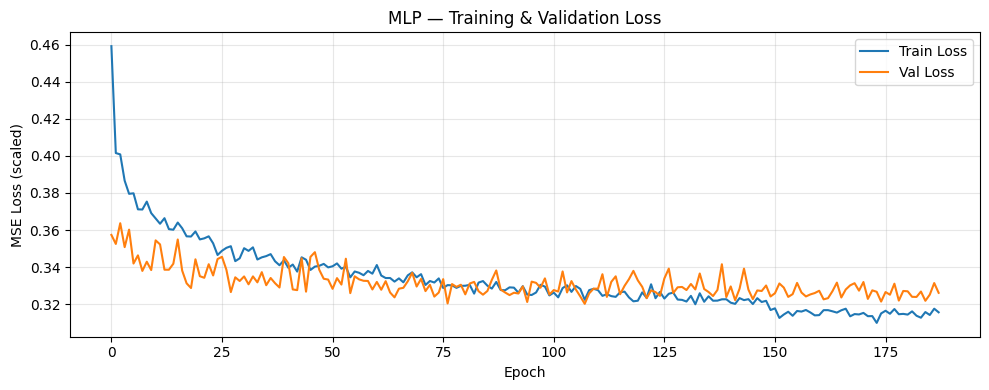

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', linewidth=1.5)
plt.plot(val_losses,   label='Val Loss',   linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (scaled)')
plt.title('MLP — Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mlp_training_curve.png', dpi=150)
plt.show()

## 7. Evaluate on Test Set

In [ ]:
model.load_state_dict(torch.load('mlp_best.pt'))
model.eval()

with torch.no_grad():
    y_pred_sc = model(X_test_t).cpu().numpy()

y_pred = y_scaler.inverse_transform(y_pred_sc)

print(f'{"Target":<30} {"MAE":>8} {"RMSE":>8} {"R²":>8}')
print('-' * 58)
results = {}
for i, col in enumerate(TARGET_COLS):
    mae  = mean_absolute_error(y_test[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_pred[:, i]))
    r2   = r2_score(y_test[:, i], y_pred[:, i])
    results[col] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f'{col:<30} {mae:>8.4f} {rmse:>8.4f} {r2:>8.4f}')

NameError: name 'model' is not defined

## 8. Save Model & Scalers

In [ ]:
torch.save(model.state_dict(), 'mlp_model.pt')
joblib.dump(X_scaler, 'mlp_x_scaler.pkl')
joblib.dump(y_scaler, 'mlp_y_scaler.pkl')
print('Saved → mlp_model.pt')
print('Saved → mlp_x_scaler.pkl')
print('Saved → mlp_y_scaler.pkl')

Saved → mlp_model.pt
Saved → mlp_x_scaler.pkl
Saved → mlp_y_scaler.pkl


## 9. Plots — Predicted vs Actual & Residuals

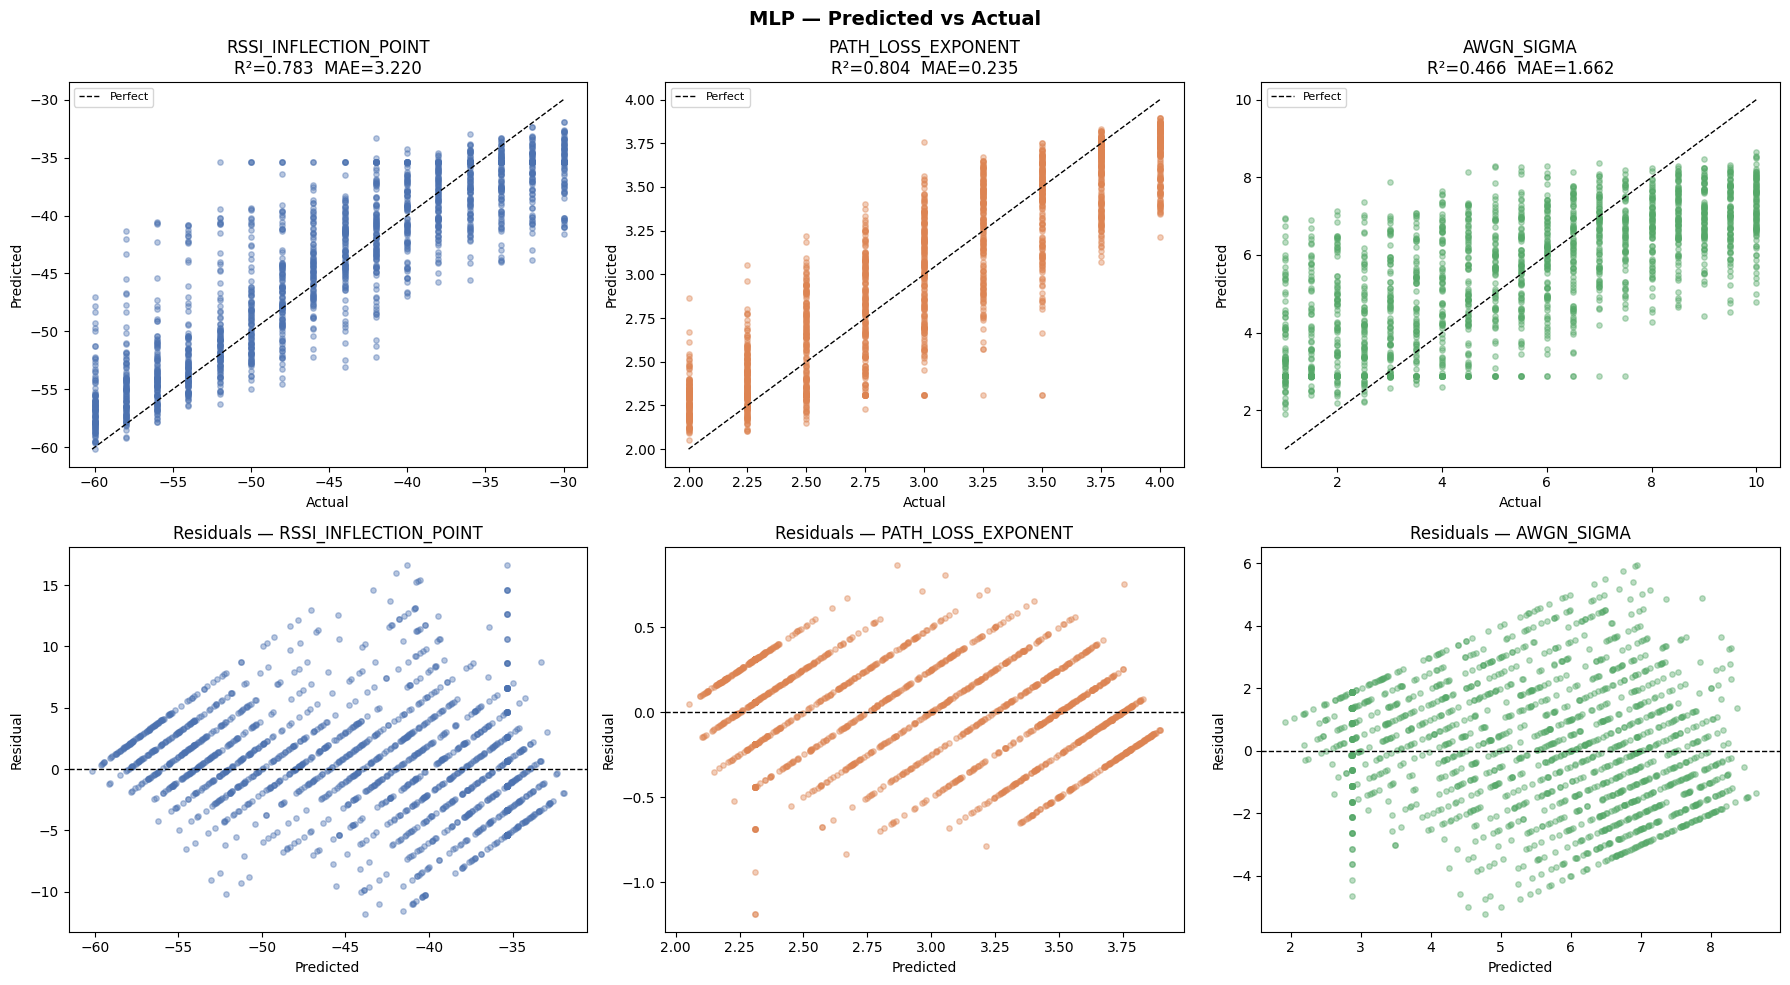

In [ ]:
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('MLP — Predicted vs Actual', fontsize=14, fontweight='bold')

for i, col in enumerate(TARGET_COLS):
    ax = axes[0, i]
    ax.scatter(y_test[:, i], y_pred[:, i], alpha=0.4, s=15, color=colors[i])
    lims = [min(y_test[:, i].min(), y_pred[:, i].min()),
            max(y_test[:, i].max(), y_pred[:, i].max())]
    ax.plot(lims, lims, 'k--', lw=1, label='Perfect')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f"{col}\nR²={results[col]['R2']:.3f}  MAE={results[col]['MAE']:.3f}")
    ax.legend(fontsize=8)

    ax2 = axes[1, i]
    residuals = y_pred[:, i] - y_test[:, i]
    ax2.scatter(y_pred[:, i], residuals, alpha=0.4, s=15, color=colors[i])
    ax2.axhline(0, color='black', lw=1, ls='--')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Residual')
    ax2.set_title(f'Residuals — {col}')

plt.tight_layout()
plt.savefig('mlp_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Predict from Real KPIs
Replace the values below with your real measurements from FIT IoT-LAB

In [ ]:
# ── REPLACE WITH YOUR REAL KPIs ──────────────
rssi       =  -90  # mean_rssi_dbm
loss_rate  =  26.22   # loss_rate_pct
throughput =  28.4 # throughput_pkt_s
delay      =  0.419028   # mean_delay_s
# ─────────────────────────────────────────────

loss_x_delay        = loss_rate  * delay
loss_x_throughput   = loss_rate  * throughput
delay_x_throughput  = delay      * throughput
rssi_x_loss         = rssi       * loss_rate
rssi_x_delay        = rssi       * delay
throughput_per_loss = throughput / (loss_rate + 1e-6)
delay_per_loss      = delay      / (loss_rate + 1e-6)


real_kpis = np.array([[
    rssi, loss_rate, throughput, delay,
    loss_x_delay,
    loss_x_throughput,
    delay_x_throughput,
    rssi_x_loss,
    rssi_x_delay,
    throughput_per_loss,
    delay_per_loss
]])

# Predict
x_scaled = X_scaler.transform(real_kpis)
x_tensor = torch.FloatTensor(x_scaled).to(device)

model.eval()
with torch.no_grad():
    y_scaled = model(x_tensor).cpu().numpy()

params = y_scaler.inverse_transform(y_scaled)[0]

print('── Predicted Simulation Parameters ──────────────')
for name, val in zip(TARGET_COLS, params):
    print(f'  {name:<30}: {val:.4f}')
print('\n→ Plug these values into Cooja LogisticLoss settings')


── Predicted Simulation Parameters ──────────────
  RSSI_INFLECTION_POINT         : -62.6121
  PATH_LOSS_EXPONENT            : 2.4222
  AWGN_SIGMA                    : 4.9097

→ Plug these values into Cooja LogisticLoss settings
